In [1]:
import os
import datetime
import numpy as np
import pandas as pd
from functools import partial

# Model
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Seasonal Decompose
from statsmodels.tsa.seasonal import STL

# Optimization
import optuna

# Evaluation
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Data Loading

In [9]:
stock = pd.read_csv('../data/aapl_stock_price.csv')

In [10]:
stock = stock['Close'].to_dict(orient='records')

TypeError: Series.to_dict() got an unexpected keyword argument 'orient'

In [185]:
# Convert the column to datetime format if it's not already
stock["Date"] = pd.to_datetime(stock.index)

# Now you can extract the year from the Date columnst
# stock = stock[(stock["Date"].dt.year == 2023) | (stock["Date"].dt.year == 2024)]
# stock = stock[(stock["Date"].dt.year == 2024)]

# Data Preparation

In [186]:
def train_test_split(data, split_date):
    train = data[data.index < split_date]
    test = data[data.index >= split_date]
    return train, test

In [187]:
def seasonalDecompose(y, period, is_plot=True):
    stl = STL(y, period=period)
    result = stl.fit()
    if is_plot:
        fig = result.plot() 
        fig.set_size_inches(13, 6)
        for axes in fig.axes:
            axes.grid(True)
        plt.show()
    return result

In [188]:
def feature_engineering(data, label=None):
    """
    Creates time series features
    """
    sdcompose_result = seasonalDecompose(data, period=5, is_plot=False)
    df = pd.concat(
        [data, 
         sdcompose_result.trend,
         sdcompose_result.seasonal,
         sdcompose_result.resid
        ], axis=1)
    df['lag'] = df[df.columns[0]].diff()
    df['ma'] = df[df.columns[0]].rolling(window=2).mean()
    df = df.fillna(0)
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    
    X = df[[col for col in df.columns if (col != label) & (col != 'date')]]
    if label:
        y = df[label]
        return X, y
    return X

In [189]:
# Define split date
start_date = stock.index[0]
split_index = round(len(stock) * 0.8)
split_date = stock.index[split_index] 

X_train, X_test = train_test_split(stock["Close"], split_date)

X_train, y_train = feature_engineering(X_train, "Close")
X_test, y_test = feature_engineering(X_test, "Close")

# Modelling

In [190]:
def train_eval_ml_model(model, X_train, X_test, y_train, y_test):
    """
    
    """
    # Train the input
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Eval
    rmse = root_mean_squared_error(y_test, y_pred)
    return rmse

def optuna_search(objective, n_trials, direction):
    """
    
    """
    # Create study
    study = optuna.create_study(direction=direction)
    study.optimize(objective, n_trials=n_trials)

    # Display the best trial, value, and params
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    return trial.params

def xgb_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 300, 1500)  # naik, XGBoost butuh banyak trees
    max_depth = trial.suggest_int('max_depth', 4, 15)            # range lebih luas
    learning_rate = trial.suggest_loguniform('learning_rate', 0.0005, 0.2)  # learning rate sering lebih kecil
    min_child_weight = trial.suggest_int('min_child_weight', 1, 20)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 100.0)
    reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-5, 100.0)
    
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        objective='reg:squarederror'
    )
    
    rmse = train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

def rf_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)  # boleh besar, RF kuat di banyak pohon
    max_depth = trial.suggest_int('max_depth', 5, 50)            # lebih fleksibel
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)  # jangan terlalu besar
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap
    )
    
    rmse =train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

## Perform Hyperparameter Search

### XGBoost

In [191]:
# Hyperparameter tuning with xgboost
xgb_partial = partial(xgb_objective, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
xgb_best_params = optuna_search(xgb_partial, 100, "minimize")

[I 2025-04-27 21:18:00,017] A new study created in memory with name: no-name-04415c76-7360-416b-8a6d-e5e74fb7b4ea
C:\Users\fadhil\AppData\Local\Temp\ipykernel_27504\2812831533.py:37: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.0005, 0.2)  # learning rate sering lebih kecil
C:\Users\fadhil\AppData\Local\Temp\ipykernel_27504\2812831533.py:41: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 100.0)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_27504\2812831533.py:42: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed i

Best trial:
  Value: 30.451187712683964
  Params: 
    n_estimators: 1283
    max_depth: 14
    learning_rate: 0.16915192280133656
    min_child_weight: 4
    subsample: 0.854328776368114
    colsample_bytree: 0.9573295800430177
    reg_alpha: 1.6559237813866342e-05
    reg_lambda: 4.197611354433197


In [192]:
xgb_model = XGBRegressor(**xgb_best_params, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)
y_predict = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 30.451187712683964 | MAE : 19.853959954303242, | MAPE : 0.09034599393894203


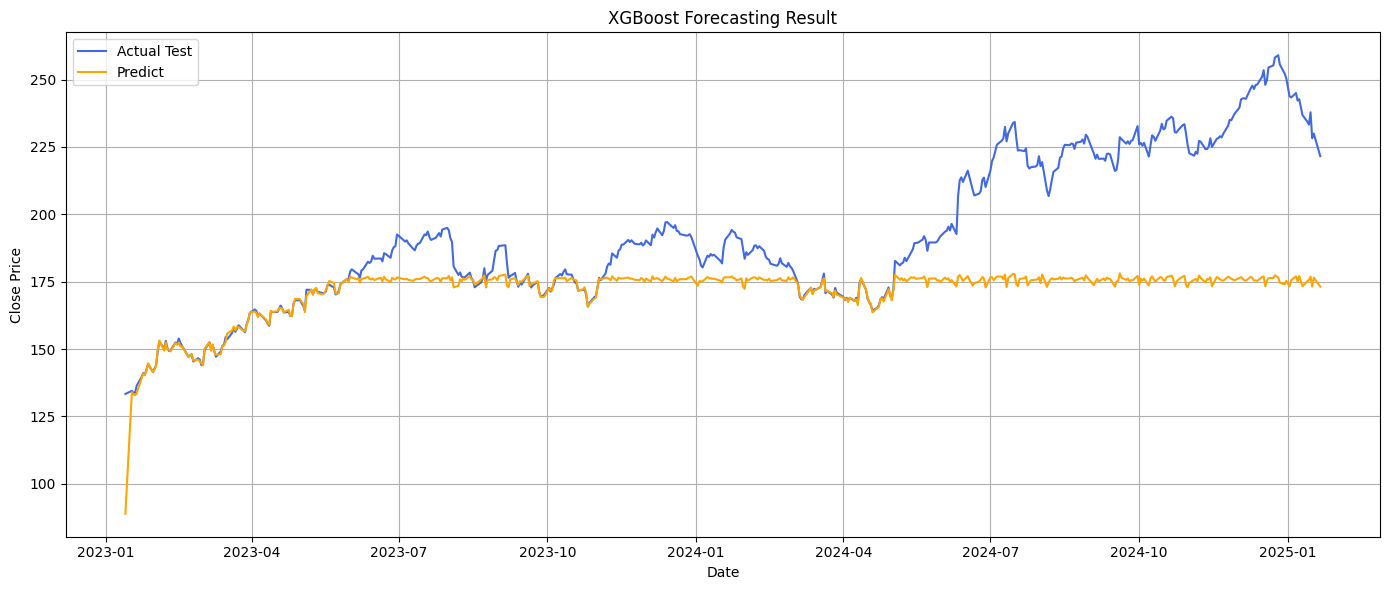

In [193]:
# Pastikan y_predict array
y_predict = np.array(y_predict)

# Samakan panjang y_test dan y_predict
min_len = min(len(y_predict), len(y_test))
y_predict = y_predict[:min_len]
y_test = y_test.iloc[:min_len]

# Buat mask valid
mask = ~np.isnan(y_predict)

plt.figure(figsize=(14,6))

# Plot train
# plt.plot(y_train.index, y_train.values, label='Actual Train', color='royalblue')

# Plot test TIDAK pakai sambung dari train
plt.plot(y_test.index, y_test.values, label='Actual Test', color='royalblue')

# Plot prediksi
plt.plot(y_test.index[mask], y_predict[mask], label='Predict', color='orange')

# Garis vertical split
# split_date = y_test.index[0]
# plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

# Styling
plt.title('XGBoost Forecasting Result')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Random Forest

In [194]:
# Hyperparameter tuning with xgboost
rf_partial = partial(rf_objective, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
rf_best_params = optuna_search(rf_partial, 100, "minimize")

[I 2025-04-27 21:22:32,748] A new study created in memory with name: no-name-35491e7d-7e11-43dc-bd85-f6f9cc4db9ab
[I 2025-04-27 21:22:34,635] Trial 0 finished with value: 30.54024293534328 and parameters: {'n_estimators': 212, 'max_depth': 33, 'min_samples_split': 8, 'min_samples_leaf': 2, 'bootstrap': True}. Best is trial 0 with value: 30.54024293534328.
[I 2025-04-27 21:22:37,367] Trial 1 finished with value: 30.624699012844918 and parameters: {'n_estimators': 334, 'max_depth': 44, 'min_samples_split': 10, 'min_samples_leaf': 4, 'bootstrap': True}. Best is trial 0 with value: 30.54024293534328.
[I 2025-04-27 21:22:38,346] Trial 2 finished with value: 32.35655955085657 and parameters: {'n_estimators': 172, 'max_depth': 50, 'min_samples_split': 10, 'min_samples_leaf': 20, 'bootstrap': True}. Best is trial 0 with value: 30.54024293534328.
[I 2025-04-27 21:22:39,356] Trial 3 finished with value: 30.684369062052372 and parameters: {'n_estimators': 103, 'max_depth': 33, 'min_samples_split'

Best trial:
  Value: 30.313648919387578
  Params: 
    n_estimators: 124
    max_depth: 36
    min_samples_split: 10
    min_samples_leaf: 3
    bootstrap: False


In [195]:
rf_model = RandomForestRegressor(**rf_best_params)
rf_model.fit(X_train, y_train)
y_predict = rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 30.34794381129376 | MAE : 19.7475951454417, | MAPE : 0.09004950752175801


In [196]:
len(y_predict)

506

In [197]:
len(y_test)

506

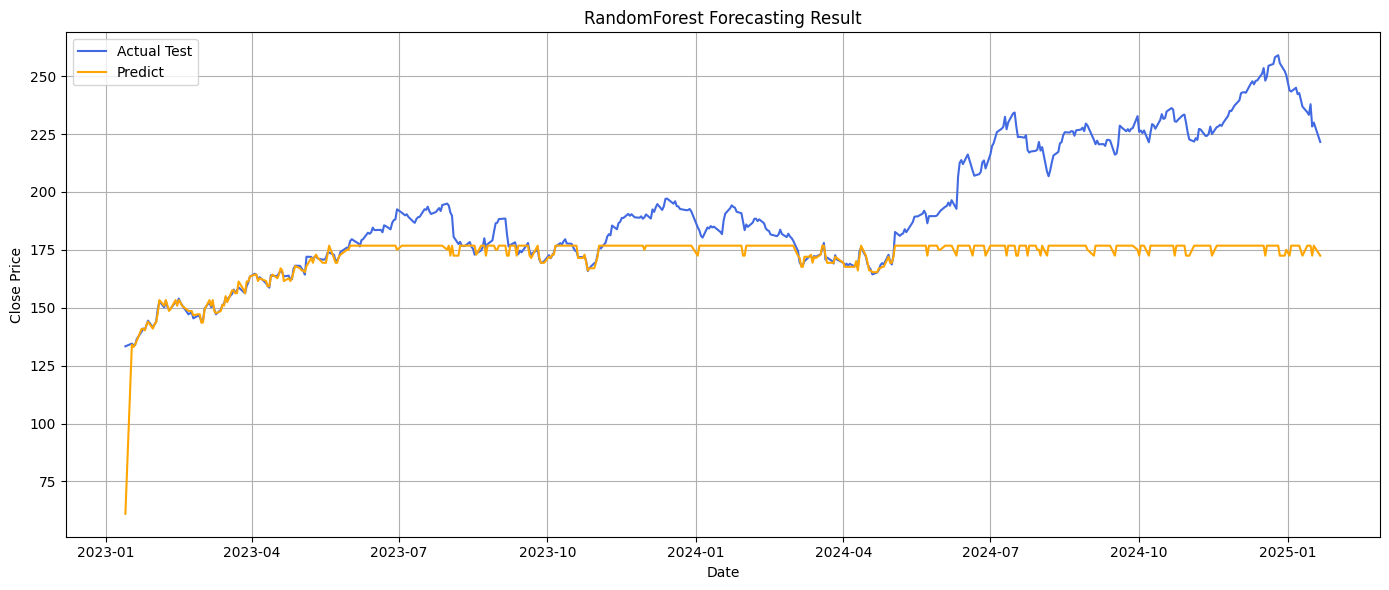

In [198]:
# Pastikan y_predict array
y_predict = np.array(y_predict)

# Samakan panjang y_test dan y_predict
min_len = min(len(y_predict), len(y_test))
y_predict = y_predict[:min_len]
y_test = y_test.iloc[:min_len]

# Buat mask valid
mask = ~np.isnan(y_predict)

plt.figure(figsize=(14,6))

# Plot train
# plt.plot(y_train.index, y_train.values, label='Actual Train', color='royalblue')

# Plot test TIDAK pakai sambung dari train
plt.plot(y_test.index, y_test.values, label='Actual Test', color='royalblue')

# Plot prediksi
plt.plot(y_test.index[mask], y_predict[mask], label='Predict', color='orange')

# # Garis vertical split
# split_date = y_test.index[0]
# plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

# Styling
plt.title('RandomForest Forecasting Result')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()